In [2]:
from typing import TypedDict

from langgraph.graph import StateGraph,START,END



def addition(state):
    print('addition',state)
    return {'x':state['x']+1}

def subtraction(state):
    print(state)
    return {'y':state['x']-2}

class State(TypedDict):
    x:int
    y:int

builder=StateGraph(State)

builder.add_node('addition',addition)
builder.add_node('subtraction',subtraction)

builder.add_edge(START,'addition')
builder.add_edge('addition','subtraction')
builder.add_edge('subtraction',END)

graph=builder.compile()

initial_state={'x':10}
graph.invoke(initial_state)


addition {'x': 10}
{'x': 11}


{'x': 11, 'y': 9}

In [3]:
import operator
from typing import Annotated,TypedDict,List

class State(TypedDict):
    messages:Annotated[List[str],operator.add]

In [4]:
def addition(state):
    print('addition',state)
    msg=state['messages'][-1]
    response={'x':msg['x']+1}
    return {'messages':[response]}

def subtraction(state):
    print('subtraction',state)
    msg=state['messages'][-1]
    response={'x':msg['x']-2}
    return {'messages':[response]}

builder=StateGraph(State)

builder.add_node('addition',addition)
builder.add_node('subtraction',subtraction)

builder.add_edge(START,'addition')
builder.add_edge('addition','subtraction')
builder.add_edge('subtraction',END)

graph=builder.compile()
    

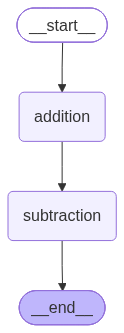

In [5]:
from IPython.display import Image,display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [6]:
input_state={'messages':[{'x':10}]}
graph.invoke(input_state)

addition {'messages': [{'x': 10}]}
subtraction {'messages': [{'x': 10}, {'x': 11}]}


{'messages': [{'x': 10}, {'x': 11}, {'x': 9}]}

In [7]:
graph.invoke({'messages':[{'x':32}]})

addition {'messages': [{'x': 32}]}
subtraction {'messages': [{'x': 32}, {'x': 33}]}


{'messages': [{'x': 32}, {'x': 33}, {'x': 31}]}